# Squeezed MZI input for phase sensing

In this notebook, I present a basic simulation of the Mach Zehnder interferometer(MZI) with an electrically indiced phase-shift in one MZI arm. The first input channel of the MZI is recieves a coherent laser field, characterized by its amplitude $\alpha=|\alpha|e^{i\phi_\text{in}}$, while the second receives a squeezed vacuum state, characterized the decibel of squeezing, for which we will consider $0-16$ dB. This should be in line with the figure given below:

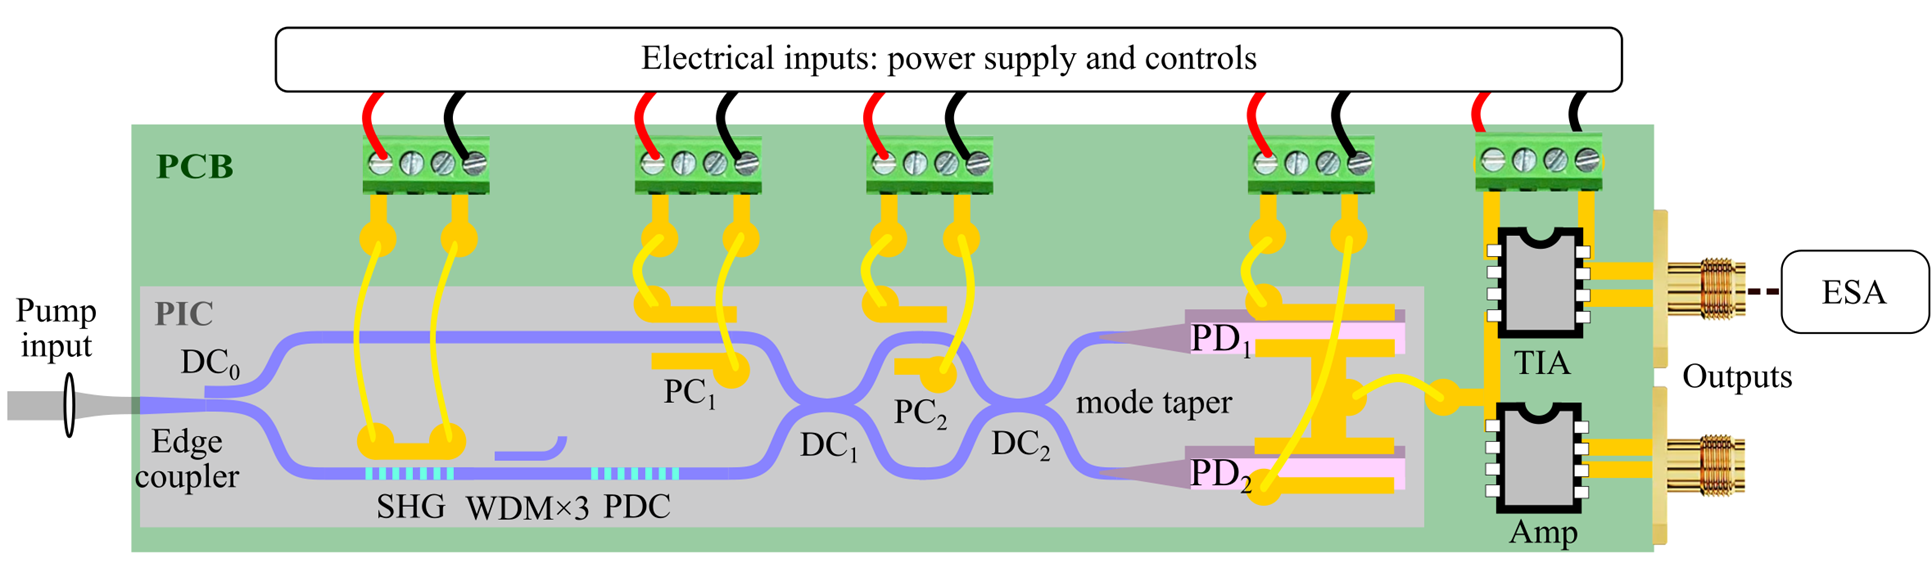

For a linear coupler (any unitary linear circuit, characterized by a unitary $U$, actually), there is no need to perform a full (quasi)exact quantum simulation, e.g., using tensor-network simulation methods, but the framework of a linear operator transform is sufficient and exact within the Gaussian manifold of quantum states.

For this, we make the transformation, $\hat{a}_i \rightarrow \sum_j U_{ij}\hat{a}_j$, and calculate it through in the Gaussian operator expectation values $\langle \cdot \rangle$. We define the relevant correlators, up to second order,
$$
\alpha_i:=\langle \hat{a}_i \rangle, \;\;\; N_{ij} := \langle \delta\hat{a}^\dagger_i \delta\hat{a}_j\rangle \;\;\; C_{ij} := \langle \delta\hat{a}_i \delta\hat{a}_j\rangle,
$$
with $\delta \hat{a}_i:= \hat{a}_i-\alpha_i$ the mean-zero Gaussian fluctuation operators, and find that they follow the linear tranformations
$$
\vec{\alpha} \rightarrow U\vec{\alpha} \;\;\; N \rightarrow U^\ast N U^T \;\;\; C \rightarrow U C U^T.
$$

In the end we want to compute the Gaussian Fisher information (GFI) for the sensing or metrology of the (perturbatively small) electric field in the first MZI arm ($PC_2$, in the figure), causing a small phase shift $\theta$. I consider it now in its simplest form, without considering cross-correlations between waveguides, only the signal-to-noise ratio of the different circuit outputs,
$$
\mathcal{F}_G := \sum_i \frac{1}{\sigma_i^2}\left(\frac{\partial n_i}{\partial\phi}\right) ^2,
$$
with $n_i:=\langle\hat{n}_i \rangle$ the intensity of mode $i$, where $\hat{n}_i=\hat{a}^\dagger_i \hat{a}_i$ is the density operator, and $\sigma^2_i := \langle \hat{n}_i \hat{n}_i \rangle - n_i^2$ the variance on the signal intensity. We want to obtain a maximal GFI, to minimize the lower bound on the variance, as given by the Cramer-Rao bound,
$$
\Delta \phi^2 \geq \frac{1}{m \mathcal{F}_G},
$$
with $m$ the number of performed measurements.

Using the expressions from above, we find the GFI with the Gaussian states obtaining the quantities; intensities,
$$
n_i = |\alpha_i|^2 + \delta n_i,
$$
so sum of classical field and fluctuations $\delta n_i =\langle \delta \hat{a}^\dagger_i \delta \hat{a_i}\rangle$, and the variances,
$$
\sigma^2_i = \langle \hat{n}_i\hat{n}_i\rangle -n_i^2 = |\alpha_i|^2 + 2|\alpha_i|^2\delta n_i + 2\text{Re} \big\{\alpha_i^{\ast 2} \delta c\big\} + \delta n(\delta n + 1) + |\delta c|^2,
$$
with $\delta c_i =\langle \delta \hat{a}_i \delta \hat{a_i}\rangle$.

From this it is clear that occupation of $c_i$, under the right phase as compared to $\alpha_i$, results in a reduction of $\sigma_i$, thus leading to fluctuations below the standard quantum limit for a coherent laser field; $\sigma^2 < |\alpha|^2$.




# The code for running the simulation

Import the libraries

In [1]:
import numpy as np
from typing import Tuple
import matplotlib.pyplot as plt

## The input state

The single-mode squeezed vacuum state can be written as,
$$
\delta n = \frac{1}{2}\cosh{2r}-\frac{1}{2}, \;\;\; \delta c= -\frac{1}{2}e^{i\varphi}\sinh{2r}
$$
with $\delta n:=\langle\delta\hat{a}^\dagger \delta\hat{a}\rangle$ and $c:=\langle\delta \hat{a} \delta\hat{a}\rangle$ the diagonal elements of the $N$ and $C$ matrices. The parameter $r$ is the (logarithm of) the squeezing amplitude. The phase $\varphi$ gives the phase of the squeezing. We will set it to $\varphi=0$, since only the relative phase w.r.t. to the coherent field counts. 

The dB of squeezing is given as $8.686 r\, \text{dB}$. Indeed, the quadrature operators $\hat{x}=\frac{1}{\sqrt{2}}\big(\hat{a} + \hat{a}^\dagger)$ and $\hat{p}=\frac{i}{\sqrt{2}}\big(\hat{a} - \hat{a}^\dagger)$ have the variances (using expressions for $n$ and $c$ and substitution with the correct commutations relations),
$$
\langle \hat{x}^2\rangle = \frac{1}{2} e^{-2r}, \;\;\; \langle \hat{p}^2\rangle = \frac{1}{2} e^{2r},
$$
giving the squeezing  $-10\log_{10} e^{-2r}\text{dB} = 20r \cdot \log_{10}e \;\text{dB}=8.686\,r\;\text{dB}$.

The function to create the cumulants $(\delta n,\delta c)$ from squeezing $r$:

In [2]:
sq_cumulants = lambda r, phi=0.: (
    0.5 * np.cosh(2. * r) - 0.5, 
    - 0.5 * np.exp(1j * phi) * np.sinh(2. * r)
    )

## The MZI circuit unitary

The circuit consists of two (symmetric) integrated couplers, characterized by the mixing angle $\theta$, with a phase shifter in the first MZI arm, giving a phase $\phi$. The following functions generate the corresponding unitaries. The last function gives the unitary of the MZI.

In [3]:
# the 2x2 unitary of a symmetric coupler
U_BS = lambda theta: np.array([
    [np.cos(theta),     1j * np.sin(theta)],
    [1j * np.sin(theta),  np.cos(theta)]
])

# the unitary of a phase shift in first arm
U_ph = lambda phi: np.array([
    [np.exp(1j*phi),  0.],
    [0.,              1.]
])

# the combined unitary of an MZI with phase shift in one arm
U_MZI = lambda theta1, phi, theta2: U_BS(theta2) @ U_ph(phi) @ U_BS(theta1)

## The cumulant transform

The next step is to generate the right transform of the cumulants under the unitary, defined in this function,

In [4]:
# the function to convert the cumulants
def cumulant_transform(U: np.ndarray, alpha: np.ndarray, N: np.ndarray, C: np.ndarray) -> Tuple[np.ndarray]:
  return U @ alpha, U.conj() @ N @ U.T, U @ C @ U.T

From the Gaussian cumulants, we derive the properties needed for obtaining the Gaussian Fisher information, as explained above.

The function to compute mean number and the variance:


In [5]:
# single-mode intensity
def get_intensity(alpha: complex, n: complex):
  return np.abs(alpha) ** 2 + n

# and variance
def get_variance(alpha: complex, n: complex, c: complex):
  return (
      np.abs(alpha) ** 2 # zeroth order
      + 2 * np.abs(alpha) ** 2 * n + 2 * (alpha**2 * np.conj(c)).real # second order
      + n**2 + n + np.abs(c)**2 # fourth order
  )

## The MZI circuit run

Finally, a function is defined to run the MZI with a phase shifter in one arm. The first input arm is a displaced coherent laser field $|\alpha_1|$ (no fluctuations $\delta n$), while the second is a squeezed vacuum state, defined by $(\delta n, \delta c)$. The circuit is run two times, one time for an MZI phase $\phi$ and one time for the perturbed $\phi +\delta \phi$ for evaluating the derivative towards $\phi$ in the GFI.

In [6]:
# run the MZI for the configuration given
def run_circuit(alpha1, n2, c2, theta1, theta2, phi, alpha2=0., n1=0., c1=0., dphi: float= 1e-3):

    # the coherent amplitudes (zero in second mode)
    alpha_in = np.array([[alpha1], [alpha2]])

    # the cumulants (diagonal input, no inter-mode coupling)
    N_in = np.array([[n1, 0.], [0., n2]])
    C_in = np.array([[c1, 0.], [0., c2]])

    # two unitaries are defined, one for the reference, unperturbed circuit (phase phi) 
    # and one for the perturbed circuit (phase phi + dphi).
    U_ref = U_MZI(theta1, phi, theta2)
    U_pert = U_MZI(theta1, phi + dphi, theta2)

    # transform cumulants in both cases
    alpha_ref, N_ref, C_ref = cumulant_transform(U_ref, alpha_in, N_in, C_in)
    alpha_pert, N_pert, C_pert = cumulant_transform(U_pert, alpha_in, N_in, C_in)

    # compute the Fisher information of two outputs from intensities and variances
    intensity_ref = get_intensity(alpha_ref.squeeze(), np.diag(N_ref))
    intensity_pert = get_intensity(alpha_pert.squeeze(), np.diag(N_pert))
    variance_ref = get_variance(alpha_ref.squeeze(), np.diag(N_ref), np.diag(C_ref))
    variance_pert = get_variance(alpha_pert.squeeze(), np.diag(N_pert), np.diag(C_pert))

    # the Gaussian Fisher information: difference in intensity outputs, normalized by the variance
    GFI = 1. / (variance_ref) * (intensity_ref - intensity_pert) ** 2 / dphi ** 2

    # return the necessary variables
    return intensity_ref.real, intensity_pert.real, variance_ref.real, variance_pert.real, GFI.real

## Example run

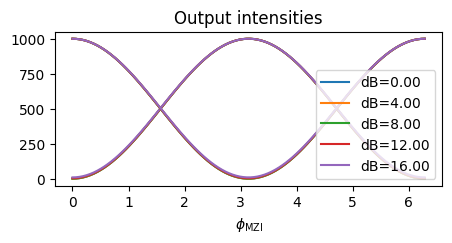

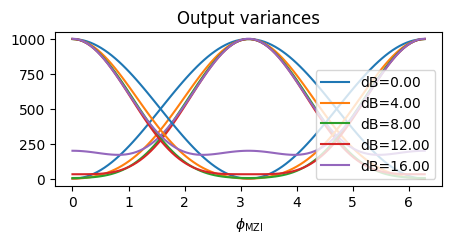

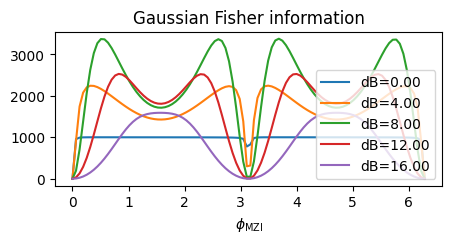

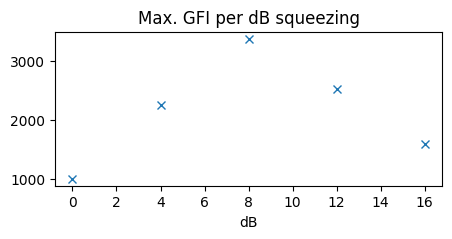

In [21]:
alpha_amp = np.sqrt(10**3) # the amplitude of the first input signal
alpha_phase = 0. # zero phase difference with squeezed vacuum
dB_squeezing_scan = np.linspace(0, 16, 5) # the dB squeezing to scan in second input arm (different lines in plot)

theta1 = 0.99 * np.pi / 4 # close to 50:50, to avoid 0/0 divergences
theta2 = np.pi / 4 #0.8 * np.pi/4

phase_MZI_scan = np.linspace(0, 2 * np.pi, 100) # the unperturbed phases in the MZI
dphi = 0.001 # the small phase fluctuation, phi' = phi + dphi, for computing the derivative in the GFI.

intensities = np.zeros((dB_squeezing_scan.size, phase_MZI_scan.size, 2))
variances = np.zeros((dB_squeezing_scan.size, phase_MZI_scan.size, 2))
FIs = np.zeros((dB_squeezing_scan.size, phase_MZI_scan.size))

for id, dB_squeezing in enumerate(dB_squeezing_scan):
    for iph, phase_MZI in enumerate(phase_MZI_scan):

        # the laser field (first input mode)
        alpha = alpha_amp * np.exp(1j * alpha_phase)

        # decibel squeezing -> compute cumulant (second input mode)
        r = dB_squeezing / 8.686
        n, c = sq_cumulants(r)

        intensity_ref, intensity_pert, variance_ref, variance_pert, FI = run_circuit(
            alpha, n, c, theta1=theta1, phi=phase_MZI,
            theta2=theta2, dphi=dphi)
    
        FIs[id, iph] = FI.sum().real # sum the two outputs
        intensities[id, iph] = intensity_ref
        variances[id, iph] = variance_ref



# the visualization
figsize = (5,2)
num_lines = dB_squeezing_scan.size
colors = plt.cm.tab10.colors[:num_lines]

plt.figure(figsize=figsize)

for i in range(num_lines):
    plt.plot(phase_MZI_scan, intensities[i,:,0], color=colors[i])
for i in range(num_lines):   
    plt.plot(phase_MZI_scan, intensities[i,:,1], color=colors[i])
plt.title("Output intensities")
plt.xlabel(r"$\phi_\text{MZI}$")
plt.legend([f"dB={dB:.2f}" for dB in dB_squeezing_scan], loc="lower right")
plt.show()
plt.close()

plt.figure(figsize=figsize)
for i in range(num_lines):   
    plt.plot(phase_MZI_scan, variances[i,:,0], color=colors[i])
for i in range(num_lines):   
    plt.plot(phase_MZI_scan, variances[i,:,1], color=colors[i])
plt.title("Output variances")
plt.xlabel(r"$\phi_\text{MZI}$")
plt.legend([f"dB={dB:.2f}" for dB in dB_squeezing_scan], loc="lower right")
plt.show()
plt.close()

plt.figure(figsize=figsize)
for i in range(num_lines): 
    plt.plot(phase_MZI_scan, FIs[i], color=colors[i])
plt.title("Gaussian Fisher information")
plt.xlabel(r"$\phi_\text{MZI}$")
plt.legend([f"dB={dB:.2f}" for dB in dB_squeezing_scan], loc="lower right")
plt.show()
plt.close()

max_FI = [np.max(FIs[i]) for i in range(dB_squeezing_scan.size)]

plt.figure(figsize=figsize)
plt.plot(dB_squeezing_scan, max_FI, "x")
plt.xlabel("dB")
plt.title("Max. GFI per dB squeezing")
plt.show()

## Quick discussion

A relatively strong field is considered of about 1000 photons input (you can calculate it back to an energy scale, $E=n_\text{ph}\hbar \omega$) and we see that a clear quantum advante can be obtained, where the signal surpasses (more than three times) the limit set by coherent laser light (the blue line (constant) in the plots). A few observation
1. Intensity remains (almost) invariant
2. Signal variance changes when the MZI phase is changed
3. Evaluating the GFI related to small phase perturbations (~ electric field fluctuations) leads to a quantum benefit when the right zero phase is considered in the MZI
4. For these cases, 8 dB of squeezing gives the best results (three times improvement) -- but this changes if you vary the other parameters.

I think this would actually be an interesting work, if this experiment can be performed in the lab. I am not fully up-to-date on the status in literature using squeezed-input MZI meshes for quantum sensing, but I would be surprised if it has not been considered yet. 

In any case, for the simulation of the squeezed-state MZI considered, you can get a three-fold enhancement in signal-to-noise ratio for performing sensing or metrology experiments on small electric field perturbations in $PC_2$ in the figure.

Multimode circuits, nor nonlinearities are considered yet, but they could be added relatively easy. In the linear case, everything can be contained in the multi-mode unitary of the circuit, as explained for the two-mode case. For nonlinear networks, the operators transform becomes symplectic, to first relevant order. But my feeling is that the 16 dB sueezing you already have will by far outperform any additional squeezing generated by the nonlinearity of the circuit.  

In [24]:
def random_unitary(n):
    """
    Generates a random n x n unitary matrix U using the QR decomposition.
    The resulting matrix is distributed with Haar measure.
    """
    # 1. Generate a complex matrix with elements from a standard normal distribution
    #    (Gaussian Unitary Ensemble - GUE)
    Z = np.random.standard_normal(size=(n, n)) + 1j * np.random.standard_normal(size=(n, n))

    # 2. Perform QR decomposition
    Q, R = np.linalg.qr(Z)

    # 3. Adjust the diagonal of R to ensure a uniform (Haar) distribution
    #    (This step normalizes the phases of the columns to get proper Haar measure distribution)
    diagonal_signs = np.diag(R) / np.abs(np.diag(R))
    U = Q @ np.diag(diagonal_signs)

    return U

In [45]:
L = 2

alpha = np.sqrt(1000)
dB_squeezing = 16

alphas = np.array([0. if l==0 else alpha for l in range(L)])[:, np.newaxis]

n, c = sq_cumulants(dB_squeezing / 8.686)
N = np.zeros((L,L), dtype=complex)
C = np.zeros((L,L), dtype=complex)
N[0,0] = n
C[0,0] = c

U = random_unitary(L)

# transformed cumulants
alphas_out, N_out, C_out = cumulant_transform(U, alphas, N, C)


Is = get_intensity(alphas_out.T, np.diag(N_out))
sigmas = get_variance(alphas_out.T, np.diag(N_out), np.diag(C_out))

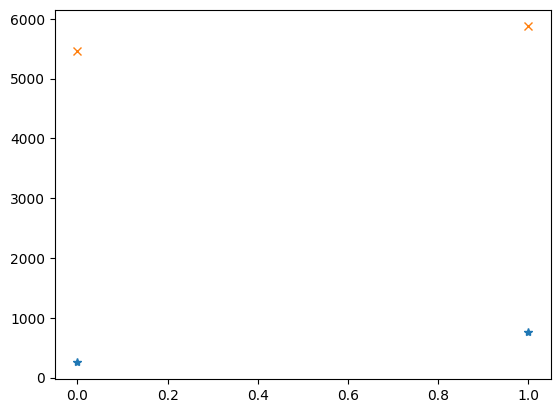

In [46]:
plt.plot(Is.T, "*")
plt.plot(sigmas.T, "x")
plt.show()